In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('cashflow.csv', sep = ';')

In [3]:
# DF PREPROCESSING
#########################################################
df['VALOR'] = df['VALOR'].str.replace(',', '.').str.replace('\u00a0', '').astype(float)
df['D. VALOR'] = pd.to_datetime(df['D. VALOR'])
df['YearMonth'] = df['D. VALOR'].dt.to_period('M')
df = df.loc[df['D. VALOR']>='2024-11-26']
df = df.loc[df['D. VALOR']<='2025-06-01']
df_1 = df.loc[df['DESCRIÇÃO']!='DROP']
df_1.loc[df['VALOR']<=0,'expense'] = df_1['VALOR']
df_1.loc[df['VALOR']>0,'income'] = df_1['VALOR']
#########################################################


# IDENTIFYING OUTLIERS
#########################################################

# Drop NaNs temporarily for IQR calculation
q1 = df_1['expense'].dropna().quantile(0.25)
q3 = df_1['expense'].dropna().quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Create 'outlier' column: True if value is outside bounds, False if within, NaN if expense is NaN
df_1['outlier'] = df_1['expense'].apply(
    lambda x: False if pd.isna(x) else not (lower_bound <= x <= upper_bound)
)

df_1.loc[df_1['expense'].isin([-120,-221.29]),'outlier'] = False
############################################################

# GROUPING
############################################################
df_2 = df_1.loc[df_1['outlier']==False].copy()
df_grouped = df_2.groupby(['YearMonth']).agg({
    'expense': 'sum',
    'income': 'sum'
}).reset_index()
df_grouped = df_grouped.rename(columns={
    'expense': 'expense_total',
    'income': 'income_month'
})

df_grouped['remainder'] = df_grouped['income_month'] + df_grouped['expense_total']
############################################################

C:\Users\w10\AppData\Local\Temp\ipykernel_17036\2366148501.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1.loc[df['VALOR']<=0,'expense'] = df_1['VALOR']
C:\Users\w10\AppData\Local\Temp\ipykernel_17036\2366148501.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1.loc[df['VALOR']>0,'income'] = df_1['VALOR']
C:\Users\w10\AppData\Local\Temp\ipykernel_17036\2366148501.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

In [6]:
df_grouped.iloc[:-1]

,YearMonth,expense_total,income_month,remainder
0,2024-11,-318.62,2984.88,2666.26
1,2024-12,-1560.18,3204.36,1644.18
2,2025-01,-1306.20,2674.15,1367.95
3,2025-02,-1295.41,2441.55,1146.14
4,2025-03,-2048.62,5586.00,3537.38
5,2025-04,-1559.24,2871.35,1312.11
6,2025-05,-1623.28,2713.35,1090.07


C:\Users\w10\AppData\Local\Temp\ipykernel_17036\3287740588.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['YearMonth'] = df_plot['YearMonth'].astype(str)


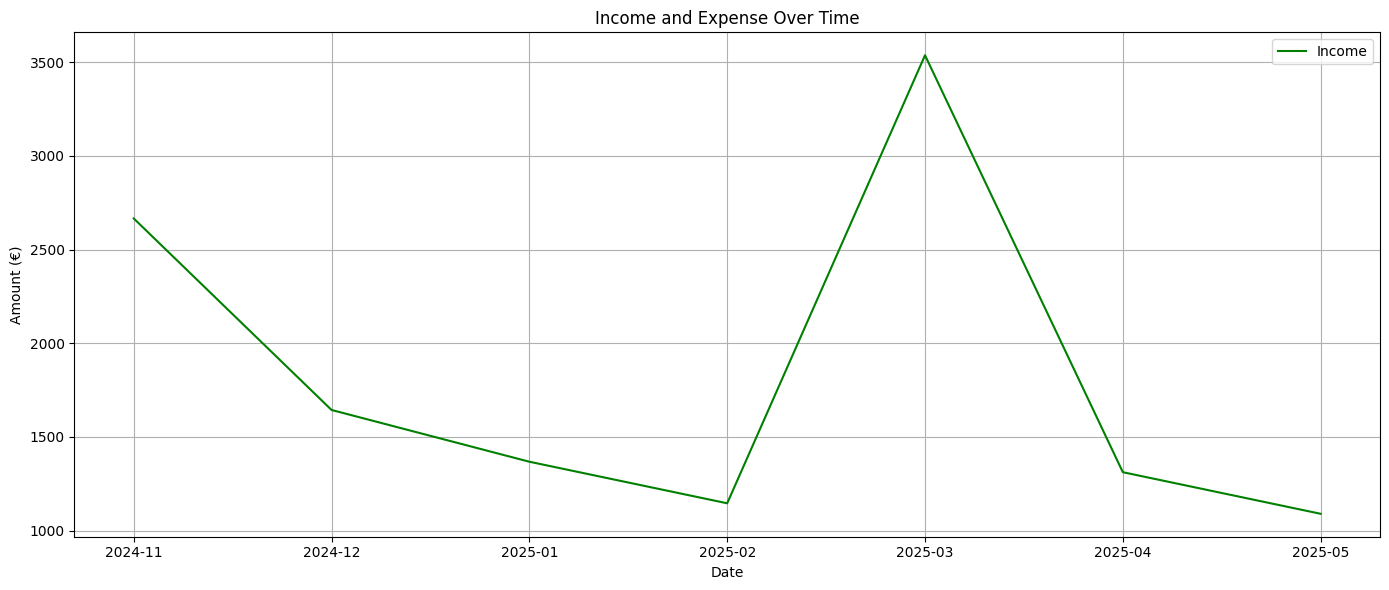

In [10]:
df_plot = df_grouped.iloc[:-1]

# Convert YearMonth to string or datetime object
df_plot['YearMonth'] = df_plot['YearMonth'].astype(str)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))

plt.plot(df_plot['YearMonth'], df_plot['remainder'], label='Income', color='green')

plt.title('Income and Expense Over Time')
plt.xlabel('Date')
plt.ylabel('Amount (€)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
df_2.loc[~df_2['expense'].isna()]

,D. VALOR,D. CONTABILÍSTICA,D. OPERAÇÃO,TIPO OPERAÇÃO,DESCRIÇÃO,REFERÊNCIA,VALOR,SALDO,DIVISA,YearMonth,expense,income,outlier
97,2024-11-26,2024-11-26,2024-11-26,OPERAÇÕES T.V.A.,TPA-HAMBURG. DA PRACA LOUSADA,6.300000e+11,-16.20,"1 595,32",EUR,2024-11,-16.20,NaN,False
98,2024-11-27,2024-11-27,2024-11-27,OPERAÇÕES T.V.A.,TPA-FARMACIA FONSECA LOUSADA,6.300000e+11,-10.09,"1 585,23",EUR,2024-11,-10.09,NaN,False
99,2024-11-27,2024-11-27,2024-11-27,OPERAÇÕES T.V.A.,TPA-MERCADONA LOUSADA,6.300000e+11,-7.15,"1 578,08",EUR,2024-11,-7.15,NaN,False
101,2024-11-28,2024-11-28,2024-11-28,RECIBOS VÁRIOS,DD ZURICH SEGUROS,2.012131e+10,-20.79,"1 602,29",EUR,2024-11,-20.79,NaN,False
103,2024-11-27,2024-11-29,2024-11-28,OPERAÇÕES CARTÃO VISA,TPA-FARMACIA DA VILA SILVARES,6.300000e+11,-45.04,"4 225,13",EUR,2024-11,-45.04,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
506,2025-05-30,2025-06-02,2025-05-31,OPERAÇÕES CARTÃO VISA,TPA-CESAR EDGAR FERREIRA M LOUSADA,6.300000e+11,-12.00,"6 237,32",EUR,2025-05,-12.00,NaN,False
507,2025-05-31,2025-06-02,2025-05-31,OPERAÇÕES CARTÃO VISA,TPA-03-TRANSACCOES BXV - VIA VERDE,6.300000e+11,-13.60,"6 223,72",EUR,2025-05,-13.60,NaN,False
508,2025-05-30,2025-06-02,2025-06-01,COMISSÃO MANUTENÇÃO,MANUTENÇÃO DE CONTA,NaN,-5.00,"6 218,72",EUR,2025-05,-5.00,NaN,False
509,2025-05-30,2025-06-02,2025-06-01,NaN,IMP.SELO MANUTENÇÃO DE CONTA,NaN,-0.20,"6 218,52",EUR,2025-05,-0.20,NaN,False


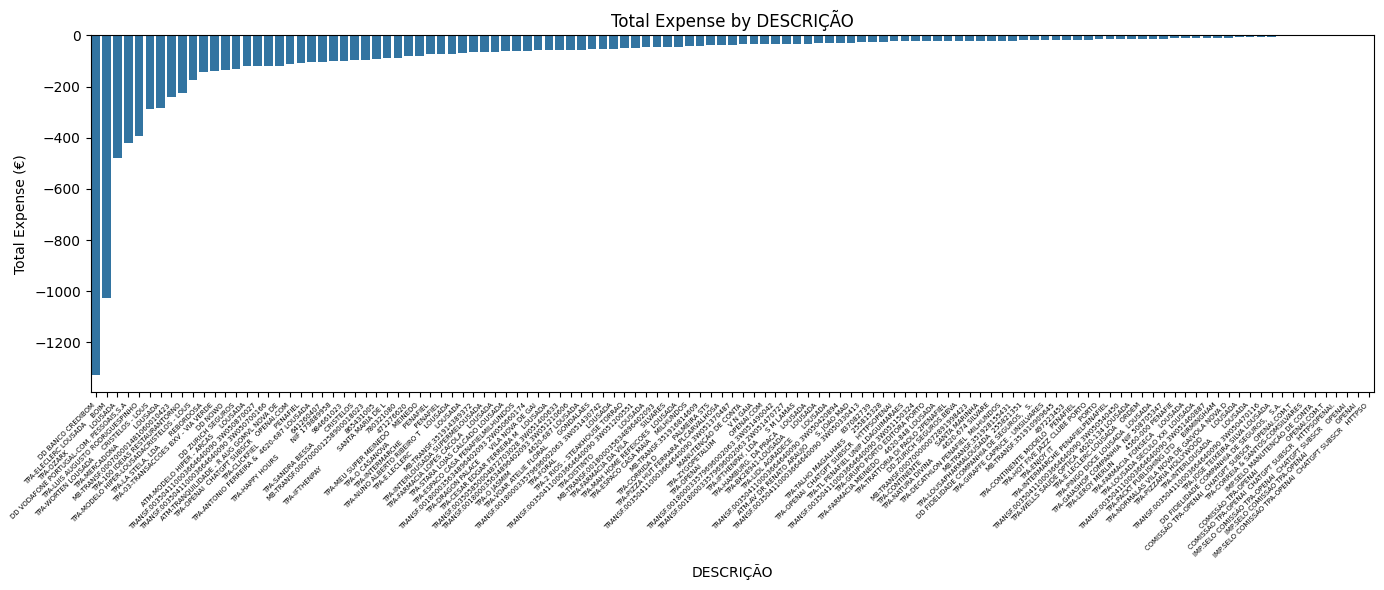

In [30]:

import matplotlib.pyplot as plt
import seaborn as sns

df_2.loc[df_2['DESCRIÇÃO']=='DD BANCO CREDIBOM, S.A.','DESCRIÇÃO'] = 'DD BANCO CREDIBOM'
df_2.loc[df_2['DESCRIÇÃO']=='TPA-E LECLERC LOUSADA   BOIM','DESCRIÇÃO'] = 'TPA-ELECLERC LOUSADA    BOIM'

expense_by_desc = df_2.loc[~df_2['expense'].isna()].groupby('DESCRIÇÃO')['expense'].sum().sort_values()

# Plot
plt.figure(figsize=(14, 6))
sns.barplot(x=expense_by_desc.index, y=expense_by_desc.values)

plt.title('Total Expense by DESCRIÇÃO')
plt.xlabel('DESCRIÇÃO')
plt.ylabel('Total Expense (€)')
plt.xticks(rotation=45, ha='right',fontsize = 5)  # Improve label readability
plt.tight_layout()
plt.show()

In [31]:
expense_by_desc.iloc[:10]

DESCRIÇÃO
DD BANCO CREDIBOM                          -1327.74
TPA-ELECLERC LOUSADA    BOIM               -1027.70
TPA-OZARK               LOUSADA             -477.30
DD VODAFONE PORTUGAL-COM. PESSOAIS,S.A      -420.02
TPA-LUIS AUGUSTO RODRIGUESPINHO             -392.50
TPA-WORTEN LOUSADA      CRISTELOS - LOUS    -286.90
TPA-MERCADONA           LOUSADA             -284.51
MB-TRANSF.000700001481060010423             -240.00
TPA-100 IDEIAS RESTAURANTORNO               -226.29
TPA-MODELO HIPER-LOUSADACRISTELOS - LOUS    -175.56
Name: expense, dtype: float64

In [20]:
df_1.loc[df_1['outlier']==True]

,D. VALOR,D. CONTABILÍSTICA,D. OPERAÇÃO,TIPO OPERAÇÃO,DESCRIÇÃO,REFERÊNCIA,VALOR,SALDO,DIVISA,YearMonth,expense,income,outlier
107,2024-11-30,2024-12-02,2024-11-30,OPERAÇÕES BANCÁRIAS,DEZEMBRO 2024,NaN,-300.00,"3 974,63",EUR,2024-11,-300.00,NaN,True
108,2024-11-30,2024-11-30,2024-11-30,OPERAÇÕES T.V.A.,TPA-CLICKFIEL PENAFIEL,6.300000e+11,-259.90,"3 714,73",EUR,2024-11,-259.90,NaN,True
131,2024-12-12,2024-12-12,2024-12-12,OPERAÇÕES T.V.A.,MB-TRANSF.351914389372,6.300000e+11,-380.00,"2 939,11",EUR,2024-12,-380.00,NaN,True
157,2024-12-24,2024-12-24,2024-12-24,OPERAÇÕES T.V.A.,"TPA-IFTHENPAY, LDA S M LAMAS",6.300000e+11,-564.00,"1 766,46",EUR,2024-12,-564.00,NaN,True
169,2024-12-30,2024-12-30,2024-12-30,OPERAÇÕES BANCÁRIAS,JANEIRO 2025,NaN,-300.00,"4 286,23",EUR,2024-12,-300.00,NaN,True
188,2025-01-09,2025-01-09,2025-01-09,OPERAÇÕES T.V.A.,"TPA-IFTHENPAY, LDA S M LAMAS",6.300000e+11,-358.00,"3 440,08",EUR,2025-01,-358.00,NaN,True
230,2025-01-31,2025-01-31,2025-01-31,RECIBOS VÁRIOS,730846215,6.300000e+11,-189.38,"4 693,88",EUR,2025-01,-189.38,NaN,True
231,2025-01-31,2025-01-31,2025-01-31,OPERAÇÕES BANCÁRIAS,FEVEREIRO 2025,NaN,-300.00,"4 393,88",EUR,2025-01,-300.00,NaN,True
247,2025-02-07,2025-02-07,2025-02-07,OPERAÇÕES T.V.A.,TPA-CHURRASQ PORTUGUESA NIF 504233840,6.300000e+11,-170.30,"4 208,98",EUR,2025-02,-170.30,NaN,True
288,2025-02-28,2025-02-28,2025-02-28,RECIBOS VÁRIOS,431365609,6.300000e+11,-150.71,"5 589,26",EUR,2025-02,-150.71,NaN,True


In [12]:
income_month + expense_total

12778.09

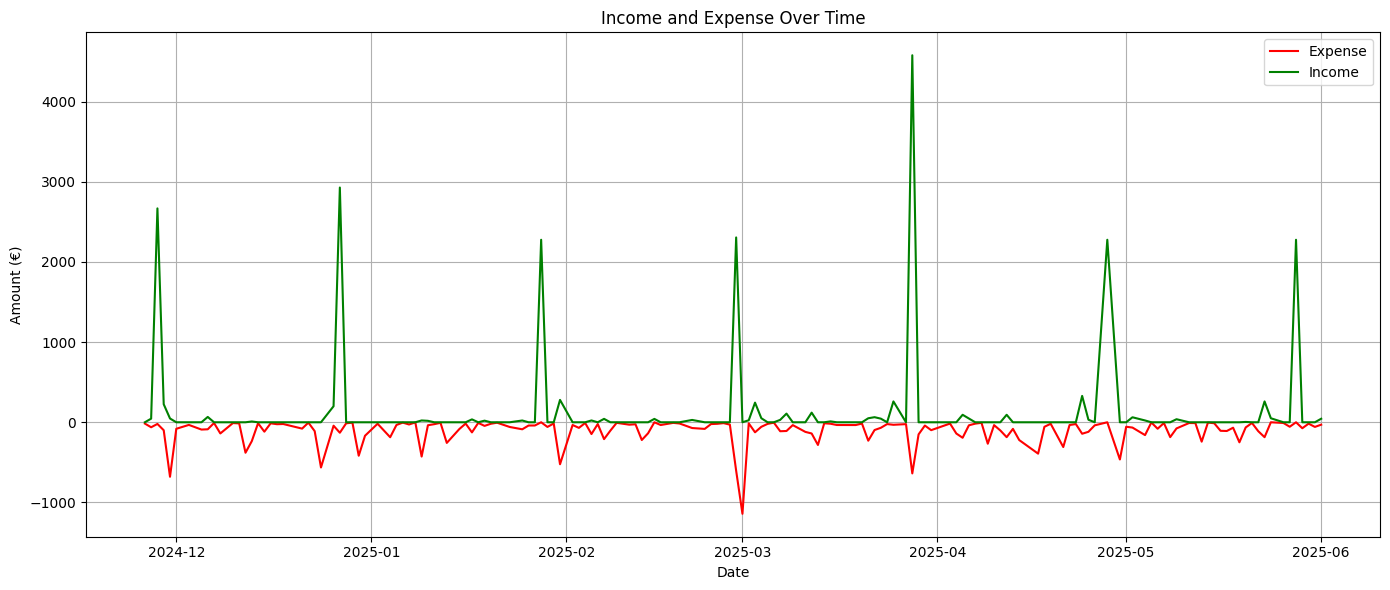

In [5]:
df_3 = df_1.groupby(['D. VALOR']).agg({
    'expense': 'sum',
    'income': 'sum'
}).reset_index()

# Plot
import matplotlib.pyplot as plt
df_plot = df_3.sort_values('D. VALOR')
plt.figure(figsize=(14, 6))

plt.plot(df_plot['D. VALOR'], df_plot['expense'], label='Expense', color='red')
plt.plot(df_plot['D. VALOR'], df_plot['income'], label='Income', color='green')

plt.title('Income and Expense Over Time')
plt.xlabel('Date')
plt.ylabel('Amount (€)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()